# MNIST Model Training

In this exercise, we'll train a simple CNN model on a small MNIST subset to create a **DNN under Test** for the subsequent AI testing exercises.

## Shared Artifacts for AI Testing Exercises

We use three directories for reusable artifacts across subsequent exercises:

| Directory | Contents |
|-----------|----------|
| `modules/exercise_artifacts/code/` | Model class definitions |
| `modules/exercise_artifacts/model/` | Saved model weights |
| `modules/exercise_artifacts/data/` | Small datasets |

In [1]:
import os, sys

# exercises → unit folder → modules → project_root
MODULES_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
CODE_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "code")
MODEL_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "model")
DATA_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "data")

if CODE_DIR not in sys.path:
    sys.path.append(CODE_DIR)

if MODEL_DIR not in sys.path:
    sys.path.append(MODEL_DIR)

if DATA_DIR not in sys.path:
    sys.path.append(DATA_DIR)

print("Added to sys.path:", CODE_DIR)
print("Added to sys.path:", MODEL_DIR)
print("Added to sys.path:", DATA_DIR)

Added to sys.path: /workspace/modules/exercise_artifacts/code
Added to sys.path: /workspace/modules/exercise_artifacts/model
Added to sys.path: /workspace/modules/exercise_artifacts/data


## Load Dataset

We use a small subset of MNIST: **1,000 training** and **200 test** samples.

**Why a small dataset?**  
Real-world ML often faces limited data, poor quality, or suboptimal models. 
By restricting our dataset, we simulate an imperfect model with testable defects—ideal for software testing exercises.

In [2]:
import torch

# Load pre-saved MNIST subsets (using DATA_DIR defined above)
train_data = torch.load(os.path.join(DATA_DIR, "mnist_train_1k.pt"))
test_data = torch.load(os.path.join(DATA_DIR, "mnist_test_200.pt"))

train_images, train_labels = train_data["images"], train_data["labels"]
test_images, test_labels = test_data["images"], test_data["labels"]

print(f"Train: {train_images.shape}, {train_labels.shape}")
print(f"Test:  {test_images.shape}, {test_labels.shape}")

Train: torch.Size([1000, 1, 28, 28]), torch.Size([1000])
Test:  torch.Size([200, 1, 28, 28]), torch.Size([200])


## Visualize Dataset

The code below displays 10 samples each from the training and test sets.

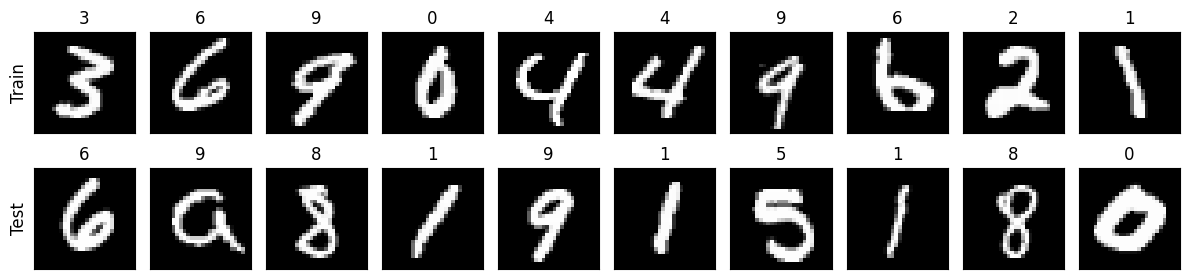

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 10, figsize=(12, 3))

# Train set (top row)
for i in range(10):
    axes[0, i].imshow(train_images[i].squeeze(), cmap='gray')
    axes[0, i].set_title(f"{train_labels[i].item()}")
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])

# Test set (bottom row)
for i in range(10):
    axes[1, i].imshow(test_images[i].squeeze(), cmap='gray')
    axes[1, i].set_title(f"{test_labels[i].item()}")
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])

# Add row labels
axes[0, 0].set_ylabel("Train", fontsize=12)
axes[1, 0].set_ylabel("Test", fontsize=12)

plt.tight_layout()
plt.show()

## Load CNN Model

The `MnistCNN` class is pre-defined in `code/mnist_model.py`. 
The code below imports it and displays the model architecture.

In [4]:
from mnist_model import MnistCNN
from torchinfo import summary

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model = MnistCNN().to(device)
print("MnistCNN Summary:")
summary(model, input_size=(1, 1, 28, 28), col_names=["input_size", "output_size", "num_params"])

Device: cpu
MnistCNN Summary:


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
MnistCNN                                 [1, 1, 28, 28]            [1, 10]                   --
├─Conv2d: 1-1                            [1, 1, 28, 28]            [1, 8, 28, 28]            80
├─Conv2d: 1-2                            [1, 8, 14, 14]            [1, 16, 14, 14]           1,168
├─Linear: 1-3                            [1, 784]                  [1, 32]                   25,120
├─Linear: 1-4                            [1, 32]                   [1, 10]                   330
Total params: 26,698
Trainable params: 26,698
Non-trainable params: 0
Total mult-adds (M): 0.32
Input size (MB): 0.00
Forward/backward pass size (MB): 0.08
Params size (MB): 0.11
Estimated Total Size (MB): 0.19

## Train MNIST Model

The code below trains our `MnistCNN` model for 10 epochs. This results in a model that performs reasonably well (~90% accuracy) while still having enough defects to test.

In [5]:
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim

# Create DataLoaders
train_dataset = TensorDataset(train_images, train_labels)
test_dataset = TensorDataset(test_images, test_labels)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
    
    train_acc = 100 * correct / len(train_dataset)
    print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {total_loss/len(train_loader):.4f} | Train Acc: {train_acc:.1f}%")


Epoch  1/10 | Loss: 2.2634 | Train Acc: 18.0%
Epoch  2/10 | Loss: 1.9044 | Train Acc: 44.5%
Epoch  3/10 | Loss: 1.1483 | Train Acc: 69.1%
Epoch  4/10 | Loss: 0.7040 | Train Acc: 79.3%
Epoch  5/10 | Loss: 0.5257 | Train Acc: 84.2%
Epoch  6/10 | Loss: 0.4105 | Train Acc: 88.5%
Epoch  7/10 | Loss: 0.3307 | Train Acc: 90.3%
Epoch  8/10 | Loss: 0.2919 | Train Acc: 91.2%
Epoch  9/10 | Loss: 0.2471 | Train Acc: 92.0%
Epoch 10/10 | Loss: 0.2249 | Train Acc: 94.0%


## Test the Model

The code below evaluates the model on the test dataset and collects correct/incorrect predictions for the following visualization.

In [6]:
# Evaluate on test set and collect correct/wrong samples
model.eval()
correct_samples = []  # (image, label)
wrong_samples = []    # (image, true_label, pred_label)

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(1)
        
        for img, true, pred in zip(images, labels, preds):
            if true == pred:
                correct_samples.append((img.cpu(), true.item()))
            else:
                wrong_samples.append((img.cpu(), true.item(), pred.item()))

# Calculate accuracy
test_acc = 100 * len(correct_samples) / len(test_dataset)
print(f"Test Accuracy: {test_acc:.1f}% ({len(correct_samples)}/{len(test_dataset)})")


Test Accuracy: 92.5% (185/200)


## Visualize Test Results

The code below displays 10 correct predictions (green) and 10 incorrect predictions (red).

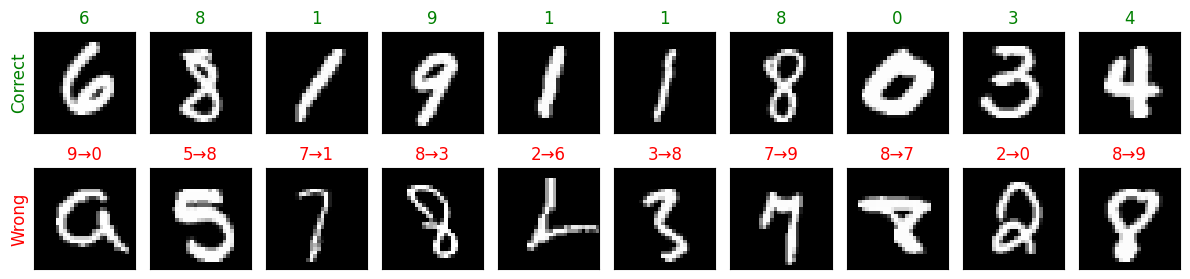

In [7]:
# Visualize test results
fig, axes = plt.subplots(2, 10, figsize=(12, 3))

# Correct samples (top row)
for i in range(min(10, len(correct_samples))):
    img, label = correct_samples[i]
    axes[0, i].imshow(img.squeeze(), cmap='gray')
    axes[0, i].set_title(f"{label}", color='green')
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])

# Wrong samples (bottom row)
for i in range(min(10, len(wrong_samples))):
    img, true, pred = wrong_samples[i]
    axes[1, i].imshow(img.squeeze(), cmap='gray')
    axes[1, i].set_title(f"{true}→{pred}", color='red')
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])

# Row labels
axes[0, 0].set_ylabel("Correct", fontsize=12, color='green')
axes[1, 0].set_ylabel("Wrong", fontsize=12, color='red')

plt.tight_layout()
plt.show()

## Save the Trained Model

The code below saves the model weights to `model/mnist_model_weights.pt` for reuse in subsequent exercises.

In [8]:
SAVE_PATH = os.path.join(MODEL_DIR, "mnist_model_weights.pt")
torch.save(model.state_dict(), SAVE_PATH)

print("Saved model to:", SAVE_PATH)

Saved model to: /workspace/modules/exercise_artifacts/model/mnist_model_weights.pt


## Load Trained Model

The code below loads a pre-trained model from saved weights. In subsequent exercises, we'll load the trained model instead of training from scratch.

In [9]:
from mnist_model import load_trained_model

device = "cuda" if torch.cuda.is_available() else "cpu"

WEIGHTS_PATH = os.path.join(MODEL_DIR, "mnist_model_weights.pt")

loaded_mnist_model = load_trained_model(WEIGHTS_PATH, device=device)

Verify that the loaded model produces the same accuracy as the model trained above.

In [10]:
# Evaluate on test set and collect correct/wrong samples
loaded_mnist_model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = loaded_mnist_model(images)
        preds = outputs.argmax(1)

# Calculate accuracy
test_acc = 100 * len(correct_samples) / len(test_dataset)
print(f"Test Accuracy: {test_acc:.1f}% ({len(correct_samples)}/{len(test_dataset)})")


Test Accuracy: 92.5% (185/200)
